In [2]:
pip install mlflow

  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached gunicorn-25.1.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.13.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached databricks_sdk-0.96.0-py3-none-any.whl.metadata (40 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached werkzeug-3.1.6-py3-none-any.whl.metadata (4.0 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached pyasn1_

# Baseline + Dataset Preprocessing + TFIDF UNIGRAM

                                                text  label
0  closet organizer install complete  now for the...      0
1  mornin all  i need to wake upthis will get me ...      1
2                         ahh he suxx he claimed it       0
3   haha i guess all the good bits were in the tr...      0
4                                  family guy funny       1

Running 5-Fold Cross Validation on TRAIN set...
Cross Validation F1 scores: [0.77353385 0.77319191 0.77137122 0.77434348 0.7729753 ]
Mean CV F1: 0.7730831531793743


2026/03/09 00:39:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 00:39:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Ejecución Exitosa
F1 Score: 0.7758395688875882
Runtime: 15.890383243560791

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.80      0.78    120129
           1       0.79      0.76      0.77    119871

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000

🏃 View run NoPunct_ElongNorm_TFIDF_Unigram_NB at: http://ec2-44-201-151-50.compute-1.amazonaws.com:5000/#/experiments/8/runs/97d5b902052c47e182e6c9a93658d8c8
🧪 View experiment at: http://ec2-44-201-151-50.compute-1.amazonaws.com:5000/#/experiments/8
   Real  Predicho
0     1         1
1     1         0
2     1         1
3     1         1
4     1         1


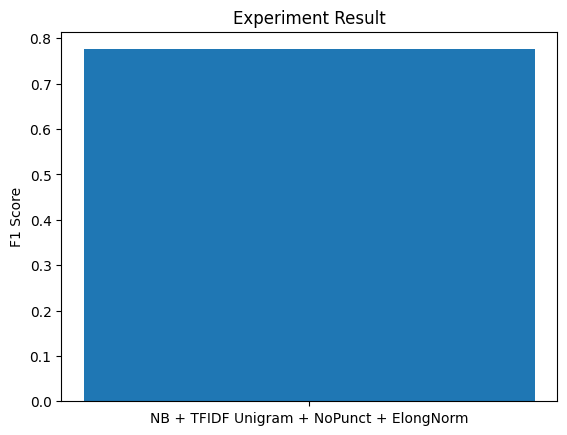

In [7]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import cross_val_score


# ===============================
# CONFIGURACIÓN MLFLOW
# ===============================

mlflow.set_tracking_uri("http://ec2-44-201-151-50.compute-1.amazonaws.com:5000")

experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)


# ===============================
# OUTPUT FOLDERS
# ===============================

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)


# ===============================
# CARGAR DATASET FINAL
# ===============================

train_df = pd.read_csv("./train_final.csv")
test_df = pd.read_csv("./test_final.csv")

print(train_df.head())


# ===============================
# FEATURES
# ===============================

X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]


# ===============================
# PIPELINE TFIDF UNIGRAM
# ===============================

pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1,1))),
    ("model", MultinomialNB(alpha=1.0))
])


# ===============================
# CROSS VALIDATION (solo TRAIN)
# ===============================

print("\nRunning 5-Fold Cross Validation on TRAIN set...")

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Cross Validation F1 scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))


# ===============================
# ENTRENAMIENTO FINAL
# ===============================

with mlflow.start_run(run_name="NoPunct_ElongNorm_TFIDF_Unigram_NB"):

    start_time = time.time()

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    end_time = time.time()

    runtime = end_time - start_time

    f1 = f1_score(y_test, y_pred, average="weighted")


    # ===============================
    # PARAMS
    # ===============================

    mlflow.log_params({
        "vectorizer": "TFIDF",
        "ngram_range": "1,1",
        "model": "MultinomialNB",
        "alpha": 1.0,
        "preprocessing": "NoPunct + ElongNorm",
        "dataset": "Sentiment140",
        "cv_folds": 5
    })


    # ===============================
    # MÉTRICAS (solo las pedidas)
    # ===============================

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("runtime_seconds", runtime)


    # ===============================
    # TAGS
    # ===============================

    mlflow.set_tag("author", "Kevin")
    mlflow.set_tag("experiment_type", "ablation")
    mlflow.set_tag("feature_type", "TFIDF")
    mlflow.set_tag("dataset", "Sentiment140")


    # ===============================
    # LOG MODEL
    # ===============================

    mlflow.sklearn.log_model(pipeline, "model")


    # ===============================
    # MODEL CARD
    # ===============================

    model_card = {
        "model_name": "NB TFIDF Unigram NoPunct + ElongNorm",
        "vectorizer": "TfidfVectorizer",
        "classifier": "MultinomialNB",
        "dataset": "Sentiment140",
        "preprocessing": "punctuation_removal + elongation_normalization",
        "f1_score": float(f1),
        "author": "Kevin"
    }

    with open("outputs/model/model_card.json", "w") as f:
        json.dump(model_card, f, indent=4)


    # ===============================
    # ABLATION TABLE
    # ===============================

    ablation_df = pd.DataFrame([{
        "vectorizer": "TFIDF",
        "ngram": "1,1",
        "model": "MultinomialNB",
        "preprocessing": "NoPunct + ElongNorm",
        "f1_score": f1
    }])

    ablation_df.to_csv("outputs/reports/ablation_results.csv", index=False)


    # ===============================
    # ABLATION PLOT
    # ===============================

    plt.figure()

    plt.bar(["NB + TFIDF Unigram + NoPunct + ElongNorm"], [f1])

    plt.ylabel("F1 Score")
    plt.title("Experiment Result")

    plt.savefig("outputs/reports/ablation_plot.png")


    # ===============================
    # SUMMARY
    # ===============================

    summary = f"""
Experiment using TF-IDF Unigram and Multinomial Naive Bayes
with punctuation removal + elongation normalization preprocessing.

F1-score achieved: {f1:.4f}

Dataset: Sentiment140
"""

    with open("outputs/reports/ablation_summary.txt", "w") as f:
        f.write(summary)


    # ===============================
    # WORK DISTRIBUTION
    # ===============================

    work_df = pd.DataFrame([{
        "member": "Kevin",
        "experiment": "NB + TFIDF Unigram + NoPunct + ElongNorm"
    }])

    work_df.to_csv("outputs/reports/work_distribution.csv", index=False)


    # ===============================
    # LOG ARTIFACTS
    # ===============================

    mlflow.log_artifact("outputs/model/model_card.json")
    mlflow.log_artifact("outputs/reports/ablation_results.csv")
    mlflow.log_artifact("outputs/reports/ablation_plot.png")
    mlflow.log_artifact("outputs/reports/ablation_summary.txt")
    mlflow.log_artifact("outputs/reports/work_distribution.csv")


    print("\nEjecución Exitosa")
    print("F1 Score:", f1)
    print("Runtime:", runtime)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


# ===============================
# COMPARACIÓN DE RESULTADOS
# ===============================

comparison_df = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred
})

print(comparison_df.head())

# Baseline + Dataset Preprocessing + TFIDF BIGRAM

                                                text  label
0  closet organizer install complete  now for the...      0
1  mornin all  i need to wake upthis will get me ...      1
2                         ahh he suxx he claimed it       0
3   haha i guess all the good bits were in the tr...      0
4                                  family guy funny       1

Running 5-Fold Cross Validation on TRAIN set...
Cross Validation F1 scores: [0.80268354 0.80142096 0.80165608 0.80222515 0.80169364]
Mean CV F1: 0.8019358722430923


2026/03/09 00:19:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 00:19:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Ejecución Exitosa
F1 Score: 0.8044604521812088
Runtime: 43.59431004524231

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.84      0.81    120129
           1       0.83      0.76      0.80    119871

    accuracy                           0.80    240000
   macro avg       0.81      0.80      0.80    240000
weighted avg       0.81      0.80      0.80    240000

🏃 View run NoPunct_ElongNorm_TFIDF_Bigram_NB at: http://ec2-44-201-151-50.compute-1.amazonaws.com:5000/#/experiments/8/runs/3885de4a8ffb4e4898f09419796f9636
🧪 View experiment at: http://ec2-44-201-151-50.compute-1.amazonaws.com:5000/#/experiments/8
   Real  Predicho
0     1         1
1     1         1
2     1         1
3     1         1
4     1         1


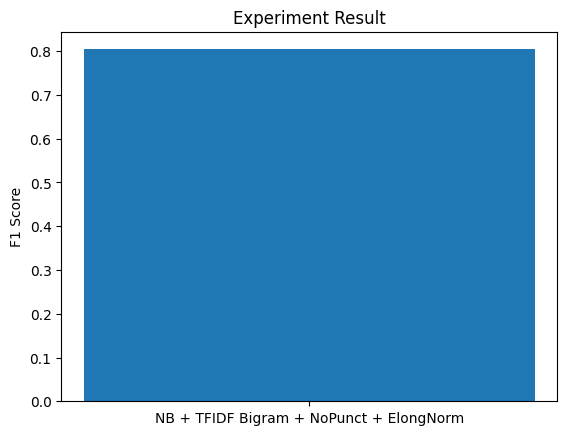

In [4]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import cross_val_score


# ===============================
# CONFIGURACIÓN MLFLOW
# ===============================

mlflow.set_tracking_uri("http://ec2-44-201-151-50.compute-1.amazonaws.com:5000")

experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)


# ===============================
# OUTPUT FOLDERS
# ===============================

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)


# ===============================
# CARGAR DATASET FINAL
# ===============================

train_df = pd.read_csv("./train_final.csv")
test_df = pd.read_csv("./test_final.csv")

print(train_df.head())


# ===============================
# FEATURES
# ===============================

X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]


# ===============================
# PIPELINE TFIDF BIGRAM
# ===============================

pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1,2))),
    ("model", MultinomialNB(alpha=1.0))
])


# ===============================
# CROSS VALIDATION (solo TRAIN)
# ===============================

print("\nRunning 5-Fold Cross Validation on TRAIN set...")

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Cross Validation F1 scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))


# ===============================
# ENTRENAMIENTO FINAL
# ===============================

with mlflow.start_run(run_name="NoPunct_ElongNorm_TFIDF_Bigram_NB"):

    start_time = time.time()

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    end_time = time.time()

    runtime = end_time - start_time

    f1 = f1_score(y_test, y_pred, average="weighted")


    # ===============================
    # PARAMS
    # ===============================

    mlflow.log_params({
        "vectorizer": "TFIDF",
        "ngram_range": "1,2",
        "model": "MultinomialNB",
        "alpha": 1.0,
        "preprocessing": "NoPunct + ElongNorm",
        "dataset": "Sentiment140",
        "cv_folds": 5
    })


    # ===============================
    # MÉTRICAS (solo las pedidas)
    # ===============================

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("runtime_seconds", runtime)


    # ===============================
    # TAGS
    # ===============================

    mlflow.set_tag("author", "Kevin")
    mlflow.set_tag("experiment_type", "ablation")
    mlflow.set_tag("feature_type", "TFIDF")
    mlflow.set_tag("dataset", "Sentiment140")


    # ===============================
    # LOG MODEL
    # ===============================

    mlflow.sklearn.log_model(pipeline, "model")


    # ===============================
    # MODEL CARD
    # ===============================

    model_card = {
        "model_name": "NB TFIDF Bigram NoPunct + ElongNorm",
        "vectorizer": "TfidfVectorizer",
        "classifier": "MultinomialNB",
        "dataset": "Sentiment140",
        "preprocessing": "punctuation_removal + elongation_normalization",
        "f1_score": float(f1),
        "author": "Kevin"
    }

    with open("outputs/model/model_card.json", "w") as f:
        json.dump(model_card, f, indent=4)


    # ===============================
    # ABLATION TABLE
    # ===============================

    ablation_df = pd.DataFrame([{
        "vectorizer": "TFIDF",
        "ngram": "1,2",
        "model": "MultinomialNB",
        "preprocessing": "NoPunct + ElongNorm",
        "f1_score": f1
    }])

    ablation_df.to_csv("outputs/reports/ablation_results.csv", index=False)


    # ===============================
    # ABLATION PLOT
    # ===============================

    plt.figure()

    plt.bar(["NB + TFIDF Bigram + NoPunct + ElongNorm"], [f1])

    plt.ylabel("F1 Score")
    plt.title("Experiment Result")

    plt.savefig("outputs/reports/ablation_plot.png")


    # ===============================
    # SUMMARY
    # ===============================

    summary = f"""
Experiment using TF-IDF Bigram and Multinomial Naive Bayes
with punctuation removal + elongation normalization preprocessing.

F1-score achieved: {f1:.4f}

Dataset: Sentiment140
"""

    with open("outputs/reports/ablation_summary.txt", "w") as f:
        f.write(summary)


    # ===============================
    # WORK DISTRIBUTION
    # ===============================

    work_df = pd.DataFrame([{
        "member": "Kevin",
        "experiment": "NB + TFIDF Bigram + NoPunct + ElongNorm"
    }])

    work_df.to_csv("outputs/reports/work_distribution.csv", index=False)


    # ===============================
    # LOG ARTIFACTS
    # ===============================

    mlflow.log_artifact("outputs/model/model_card.json")
    mlflow.log_artifact("outputs/reports/ablation_results.csv")
    mlflow.log_artifact("outputs/reports/ablation_plot.png")
    mlflow.log_artifact("outputs/reports/ablation_summary.txt")
    mlflow.log_artifact("outputs/reports/work_distribution.csv")


    print("\nEjecución Exitosa")
    print("F1 Score:", f1)
    print("Runtime:", runtime)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


# ===============================
# COMPARACIÓN DE RESULTADOS
# ===============================

comparison_df = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred
})

print(comparison_df.head())